In [71]:
##This has to be ran from parent directoty otherwise functions.func does not exist 

import xarray as xr 
import functions.funcs as funcs
import functions.plotting as plot
import matplotlib.pyplot as plt 
import geopandas as gpd
import pandas as pd
import numpy as np

### First test with CMEMS data 

- tests working with cmems data
- shows mean flow of CMEMS
- compairs to dFAD mean flow

In [2]:
ds = xr.open_dataset(r"Data\cmems.nc")
ds

<xarray.Dataset> Size: 640MB
Dimensions:    (time: 1462, depth: 15, latitude: 42, longitude: 42)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-07-01 2021-07-02 ... 2025-07-01
  * depth      (depth) float32 60B 0.494 1.541 2.646 3.819 ... 21.6 25.21 29.44
  * latitude   (latitude) float32 168B 4.417 4.5 4.583 ... 7.667 7.75 7.833
  * longitude  (longitude) float32 168B -163.8 -163.8 -163.7 ... -160.5 -160.4
Data variables:
    uo         (time, depth, latitude, longitude) float64 309MB ...
    vo         (time, depth, latitude, longitude) float64 309MB ...
    zos        (time, latitude, longitude) float64 21MB ...
Attributes:
    copernicusmarine_version:  2.2.2

In [3]:
vo  = ds['vo'] ## this is y velocity
uo = ds['uo'] ## this is x velocity

5.883611
-162.078333
<xarray.DataArray 'uo' ()> Size: 8B
array(0.471816)
Coordinates:
    depth      float32 4B 0.494
    latitude   float32 4B 5.917
    longitude  float32 4B -162.1
    time       datetime64[ns] 8B 2021-07-03
Attributes:
    units:          m s-1
    valid_min:      -3126
    standard_name:  eastward_sea_water_velocity
    long_name:      Eastward velocity
    unit_long:      Meters per second
    valid_max:      4296


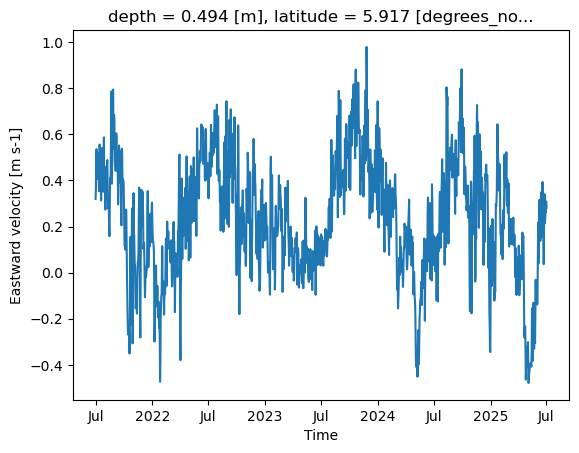

In [22]:
## plotting y velocity at palymra 
palmyra  = funcs.Palmyra_obj()
lat = palmyra.y
print(lat)
lon = palmyra.x
print(lon)

time = uo.sel(latitude = lat, longitude = lon, depth = 1, time = "2021-07-02-16.0:43.5",method = "nearest") 
print(time)
#0.319224
#0.357677
uo.sel(latitude = lat, longitude = lon, depth = 1, method = "nearest").plot()

In [5]:
## lets get time averaged x and y velocity 

vomean = vo.mean(["depth", "time"]).to_numpy()
uomean = uo.mean(["time", "depth"]).to_numpy()
latitude = ds["latitude"].to_numpy()
longitude = ds["longitude"].to_numpy()


Text(0, 0.5, 'Latitude')

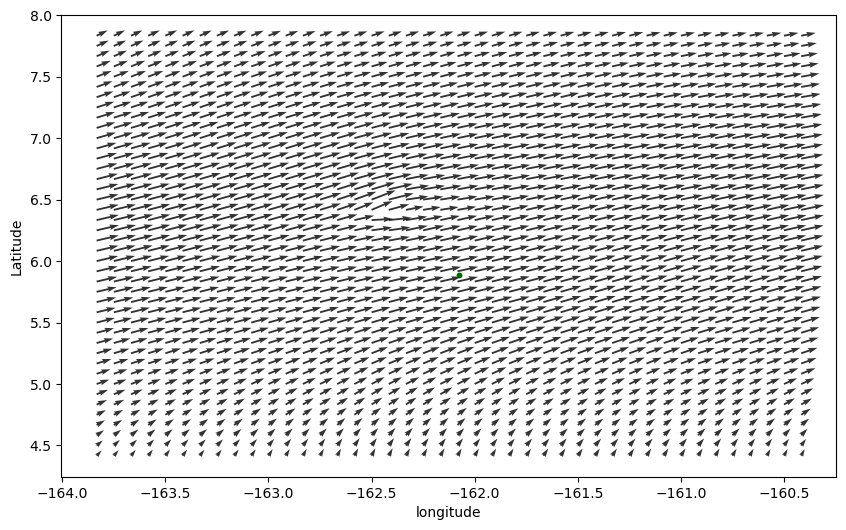

In [9]:
Xcurrents,Ycurrents = np.meshgrid(longitude, latitude)
fig,ax = plt.subplots(figsize = (10,6))
ax.quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 10, alpha = 0.8)
plot.Palmyra_plot(ax)
ax.set_xlabel("longitude")
ax.set_ylabel("Latitude")

c:\FATE\Code\functions\funcs.py:188: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:188: RuntimeWarning: invalid value encountered in divide
  heading = np.atan(delx_long/dely_long)


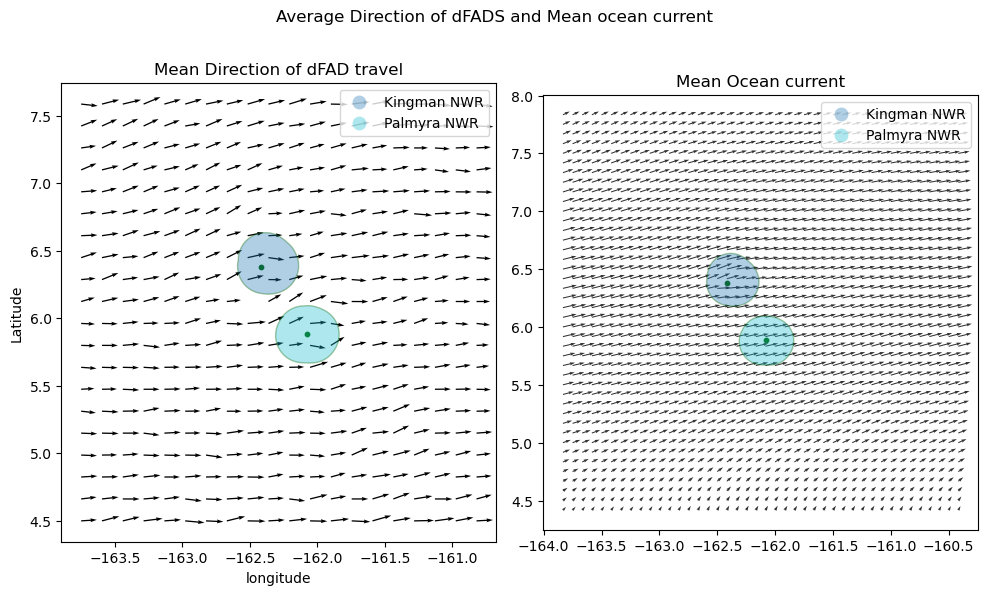

In [21]:
data = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet")
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')

data, delx_list, dely_list = funcs.add_distance_collumns(data)
lat, lon = funcs.list_of_latlon(data)

fig, ax = plt.subplots(1,2, figsize = (10,6))
plot.plotting_direction(lat, lon, delx_list=delx_list, dely_list=dely_list, ax = ax[0], scale =15, bins = 20)
ax[1].quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 9, alpha = 0.8)

plot.Palmyra_plot(ax[1])
plot.Palmyra_plot(ax[0])
plot.Kingmon_plt(ax[0])
plot.Kingmon_plt(ax[1])

ax[0].set_title("Mean Direction of dFAD travel")
ax[1].set_title("Mean Ocean current")
plot.plot_NWPs(ax[0],dataNWR)
plot.plot_NWPs(ax[1],dataNWR)
#ax[0,0].set_xlabel("longitude")
#ax[1,0].set_ylabel("Latitude")
fig.suptitle("Average Direction of dFADS and Mean ocean current")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Direction_meanocean_2.png")

### Plotting cmems movies of mean monthly currents over tropical pacific 6s - 8N, 

In [181]:
import matplotlib.animation as animation
import functions.plotting as plot 
from matplotlib import cm, colors
cmems = xr.open_dataset(r'Data\cmems_monthly.nc')
krig = xr.open_dataset(r"Data\krigging_field.nc")
cmems2023 = cmems.sel(time = slice("2023-01-01", "2024-01-01"), depth = 13.46714)
cmems2024 = cmems.sel(time = slice("2024-01-01", "2025-01-01"), depth = 13.46714)
cmems2022 = cmems.sel(time = slice("2022-01-01", "2023-01-01"), depth = 13.46714)
krig2022 = krig.sel(time = slice("2022-01-01", "2023-01-01"))
krig2023 = krig.sel(time = slice("2023-01-01", "2024-01-01"))
krig2024 = krig.sel(time = slice("2024-01-01", "2025-01-01"))
krig2022

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 366, lat: 42, lon: 42)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2022-01-01 2022-01-02 ... 2023-01-01
  * lat      (lat) float32 168B 4.417 4.5 4.583 4.667 ... 7.583 7.667 7.75 7.833
  * lon      (lon) float32 168B -163.8 -163.8 -163.7 ... -160.6 -160.5 -160.4
Data variables:
    uo       (time, lat, lon) float64 5MB ...
    vo       (time, lat, lon) float64 5MB ...

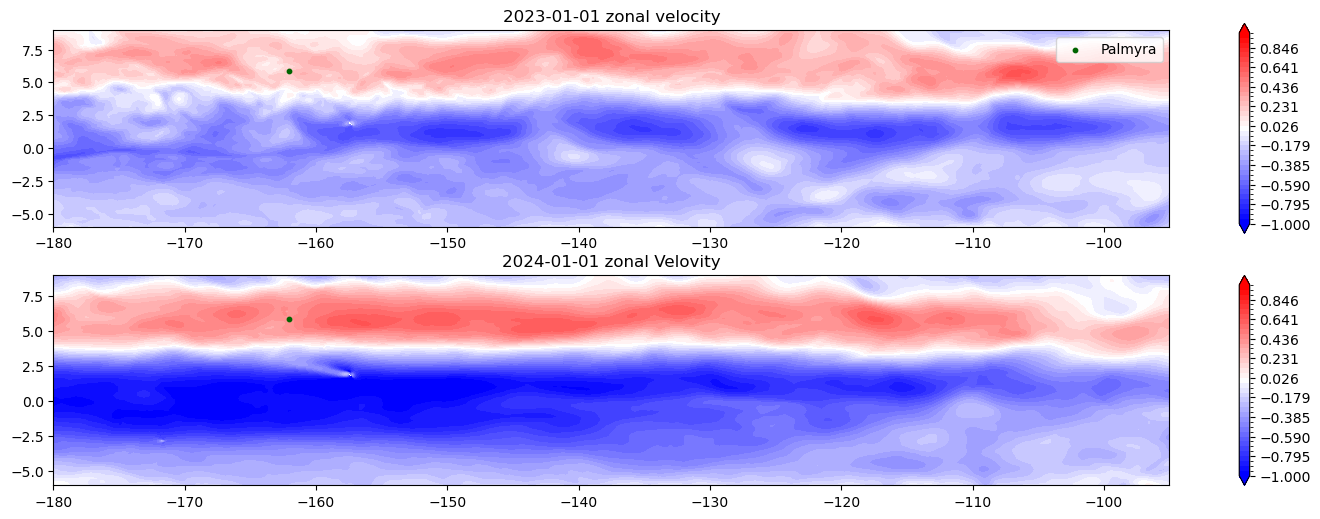

In [122]:
fig, ax = plt.subplots(2,1,figsize = (18,6))
x = cmems2023.longitude.to_numpy()
y = cmems2023.latitude.to_numpy()
X,Y = np.meshgrid(x,y)
# plot = ax.contourf(X,Y,cmems2023.uo[4,:,:] )
ax[0].set_aspect("equal")
#fig.colorbar(plot)
vmin, vmax = -1, 1 # Ensure consistent color mapping across frames
levels = np.linspace(vmin, vmax, 40)
cmap = cm.bwr
norm = colors.BoundaryNorm(levels, cmap.N)
cbar1 = ax[0].contourf(X,Y,cmems2023.uo[0,:,:], levels =levels , cmap = cmap, norm = norm, extend = "both")
cbar2 = ax[1].contourf(X,Y,cmems2024.uo[0,:,:], levels =levels , cmap = cmap, norm = norm, extend = "both")

def update(frame):
    ax[0].clear()
    contour_plot = ax[0].contourf(X,Y,cmems2023.uo[frame,:,:], levels =levels, cmap =cmap, norm = norm , extend = "both")
    contour_plot = ax[1].contourf(X,Y,cmems2024.uo[frame,:,:], levels =levels, cmap =cmap, norm = norm ,extend = "both")
    date = cmems2023.time[frame].values
    date = pd.to_datetime(date).date()
    date2 = cmems2024.time[frame].values
    date2 = pd.to_datetime(date2).date()

    ax[0].set_title(f" {date}")
    plot.Palmyra_plot(ax[0])
    plot.Palmyra_plot(ax[1])
    ax[0].legend()
    ax[0].set_title(f'{date} zonal velocity')
    ax[1].set_title(f"{date2} zonal Velovity")
nframes = cmems2023.uo.shape[0]
cbar1 = fig.colorbar(cbar1)
cbar2 = fig.colorbar(cbar2)
#plot.Palmyra_plot(ax)


ani = animation.FuncAnimation(fig, update, frames =nframes, interval = 500, blit = False)
ani.save("cmems_2023vs2024_animation.mp4", writer= 'ffmpeg')


(13, 37)
0
3
3
6
6
9
9
12


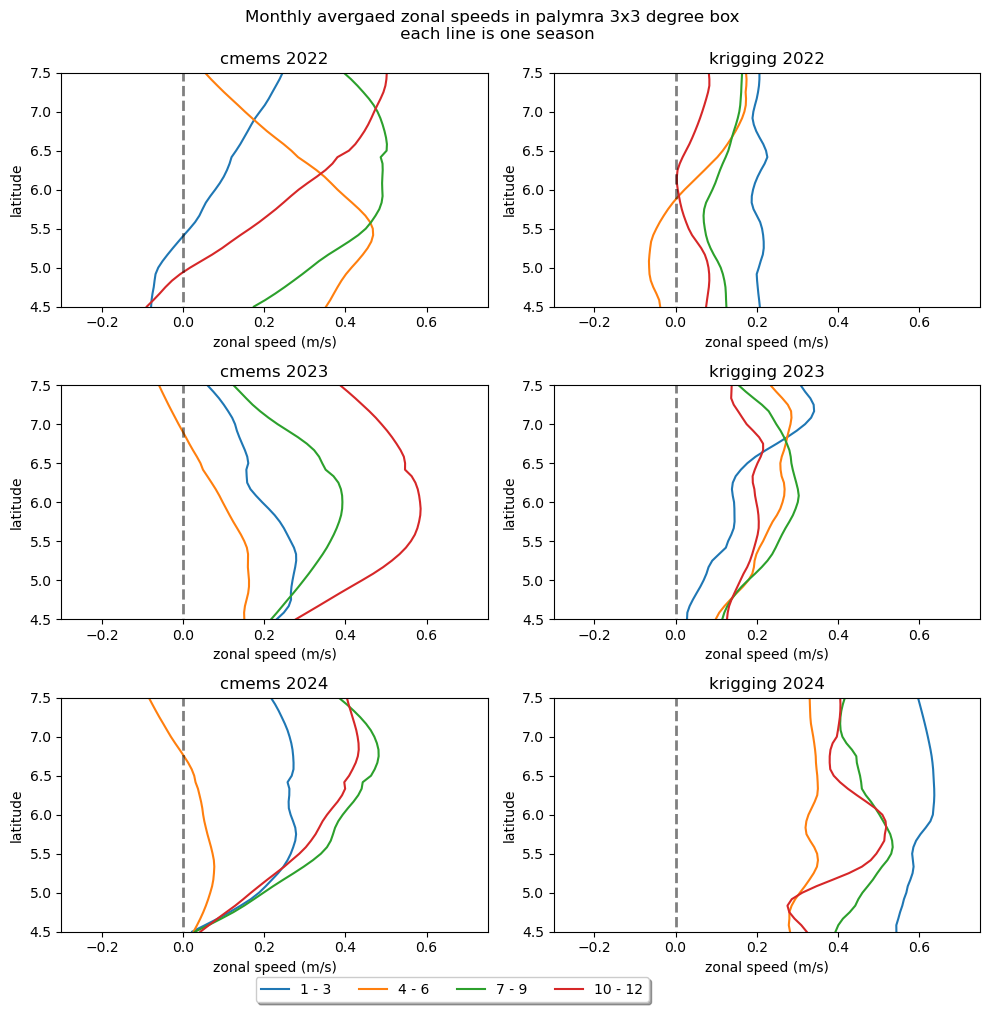

In [189]:
### Taking longitude average over our 3 degree box 

box = cmems2022.sel(latitude = slice(4.5, 7.5), longitude = slice(-163.75, -160.5))
box = box.mean(dim = "longitude")
box2 =cmems2023.sel(latitude = slice(4.5,7.5), longitude = slice(-163.74, -160.5))
box2 = box2.mean(dim = "longitude")
box3 =cmems2024.sel(latitude = slice(4.5,7.5), longitude = slice(-163.74, -160.5))
box3 = box3.mean(dim = "longitude")

box4 = krig2022.sel(lat = slice(4.5, 7.5), lon = slice(-163.75, -160.5))
box4 = box4.mean(dim = "lon")
box5 = krig2023.sel(lat = slice(4.5, 7.5), lon = slice(-163.75, -160.5))
box5 = box5.mean(dim = "lon")
box6 = krig2024.sel(lat = slice(4.5, 7.5), lon = slice(-163.75, -160.5))
box6 = box6.mean(dim = "lon")

print(box.uo.shape)
fig, ax = plt.subplots(3,2, figsize = (10,10))
for i in range(4): ## for 4 seasons
    print(i*3)
    print((i+1)*3)
    ax[0,0].plot(box.uo[i*3:(i+1)*3,:].mean(dim = "time"), box.latitude, label = f"{1+i*3} - {(i+1)*3}")
    ax[1,0].plot(box2.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude)
    ax[2,0].plot(box3.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude)

    ax[0,1].plot(box4.uo[i*3:(i+1)*3,:].mean(dim = "time"), box4.lat)
    ax[1,1].plot(box5.uo[i*3:(i+1)*3,:].mean(dim = "time"), box5.lat)
    ax[2,1].plot(box6.uo[i*3:(i+1)*3,:].mean(dim = "time"), box6.lat)

ax[0,0].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "cmems 2022")
ax[1,0].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "cmems 2023")
ax[2,0].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "cmems 2024")
ax[0,1].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "krigging 2022")
ax[1,1].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "krigging 2023")
ax[2,1].set(xlim = [-0.3, 0.75],ylim = [4.5, 7.5], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = "krigging 2024")
ax[0,0].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
ax[1,0].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
ax[2,0].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
ax[0,1].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
ax[1,1].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
ax[2,1].vlines(0, 4,8, color = "k", ls = '--', lw = 2, alpha = 0.5)
fig.suptitle("Monthly avergaed zonal speeds in palymra 3x3 degree box \n each line is one season")
fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=6)
fig.tight_layout()